In [1]:
library(readxl)
library(dplyr)

nombre_excel <- "primario_limpio.xlsx"
df <- read_excel(nombre_excel)
df_sin_outliers <- df %>%
  filter(NotaPrimerTrimestre > 1, NotaSegundoTrimestre > 1, NotaTercerTrimestre > 1)
head(df)
head(df_sin_outliers)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




CUE,institucion,departamento,EsPrivada,anioLectivo,curso,Documento,Asignatura,NotaPrimerTrimestre,NotaSegundoTrimestre,NotaTercerTrimestre,promedio,Aprobado
<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
6000270,MAESTRO LINARES CARDOSO 57 - PRIMARIO,DIAMANTE,N,2024,1ro Primario,56274610,Educacion Tecnologica,6,6,6,6.000000,Aprobado
6000270,MAESTRO LINARES CARDOSO 57 - PRIMARIO,DIAMANTE,N,2024,1ro Primario,56274610,Ciencias Naturales,6,6,6,6.000000,Aprobado
6000270,MAESTRO LINARES CARDOSO 57 - PRIMARIO,DIAMANTE,N,2024,1ro Primario,56274610,Matematica,1,1,1,1.000000,No Aprobado
6000270,MAESTRO LINARES CARDOSO 57 - PRIMARIO,DIAMANTE,N,2024,1ro Primario,56274610,Educacion Fisica,7,7,8,7.333333,Aprobado
6000270,MAESTRO LINARES CARDOSO 57 - PRIMARIO,DIAMANTE,N,2024,1ro Primario,56274610,Ciencias Sociales,6,6,6,6.000000,Aprobado
6000270,MAESTRO LINARES CARDOSO 57 - PRIMARIO,DIAMANTE,N,2024,1ro Primario,56274610,Artes Visuales,7,7,7,7.000000,Aprobado


CUE,institucion,departamento,EsPrivada,anioLectivo,curso,Documento,Asignatura,NotaPrimerTrimestre,NotaSegundoTrimestre,NotaTercerTrimestre,promedio,Aprobado
<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
6000270,MAESTRO LINARES CARDOSO 57 - PRIMARIO,DIAMANTE,N,2024,1ro Primario,56274610,Educacion Tecnologica,6,6,6,6.000000,Aprobado
6000270,MAESTRO LINARES CARDOSO 57 - PRIMARIO,DIAMANTE,N,2024,1ro Primario,56274610,Ciencias Naturales,6,6,6,6.000000,Aprobado
6000270,MAESTRO LINARES CARDOSO 57 - PRIMARIO,DIAMANTE,N,2024,1ro Primario,56274610,Educacion Fisica,7,7,8,7.333333,Aprobado
6000270,MAESTRO LINARES CARDOSO 57 - PRIMARIO,DIAMANTE,N,2024,1ro Primario,56274610,Ciencias Sociales,6,6,6,6.000000,Aprobado
6000270,MAESTRO LINARES CARDOSO 57 - PRIMARIO,DIAMANTE,N,2024,1ro Primario,56274610,Artes Visuales,7,7,7,7.000000,Aprobado
6000270,MAESTRO LINARES CARDOSO 57 - PRIMARIO,DIAMANTE,N,2024,1ro Primario,56274610,Educacion Musical,7,7,7,7.000000,Aprobado


In [2]:
table(df$Asignatura)


       Artes Visuales    Ciencias Naturales     Ciencias Sociales 
                 3552                  3552                  3552 
     Educacion Fisica     Educacion Musical Educacion Tecnologica 
                 3552                  3552                  3552 
               Lengua            Matematica 
                 3552                  3552 

In [3]:
library(dplyr)

# Filtrar por documento y obtener el total de alumnos únicos
total_alumnos_unicos <- df %>%
  distinct(Documento) %>%  # Seleccionar solo los valores únicos de la columna 'Documento'
  nrow()  # Contar el número de filas, que representa el total de alumnos únicos

# Imprimir el resultado
print(paste("Total de alumnos únicos:", total_alumnos_unicos))


[1] "Total de alumnos únicos: 3552"


In [4]:
library(dplyr)

tabla_frecuencias <- df %>%
  distinct(Documento, curso) %>%  # Seleccionar combinaciones únicas de documento y curso
  group_by(curso) %>%          # Agrupar por curso
  summarise(n = n()) %>%        # Contar estudiantes únicos en cada curso
  mutate(
    Frecuencia_Relativa = n / sum(n),
    Frecuencia_Relativa_Acumulada = cumsum(Frecuencia_Relativa),
    Frecuencia_Porcentual = Frecuencia_Relativa * 100,
    Frecuencia_Porcentual_Acumulada = cumsum(Frecuencia_Porcentual)
  )

View(tabla_frecuencias)

curso,n,Frecuencia_Relativa,Frecuencia_Relativa_Acumulada,Frecuencia_Porcentual,Frecuencia_Porcentual_Acumulada
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1ro Primario,569,0.1601914,0.1601914,16.01914,16.01914
2do Primario,590,0.1661036,0.3262950,16.61036,32.62950
3ro Primario,635,0.1787725,0.5050676,17.87725,50.50676
4to Primario,547,0.1539977,0.6590653,15.39977,65.90653
5to Primario,607,0.1708896,0.8299550,17.08896,82.99550
6to Primario,604,0.1700450,1.0000000,17.00450,100.00000


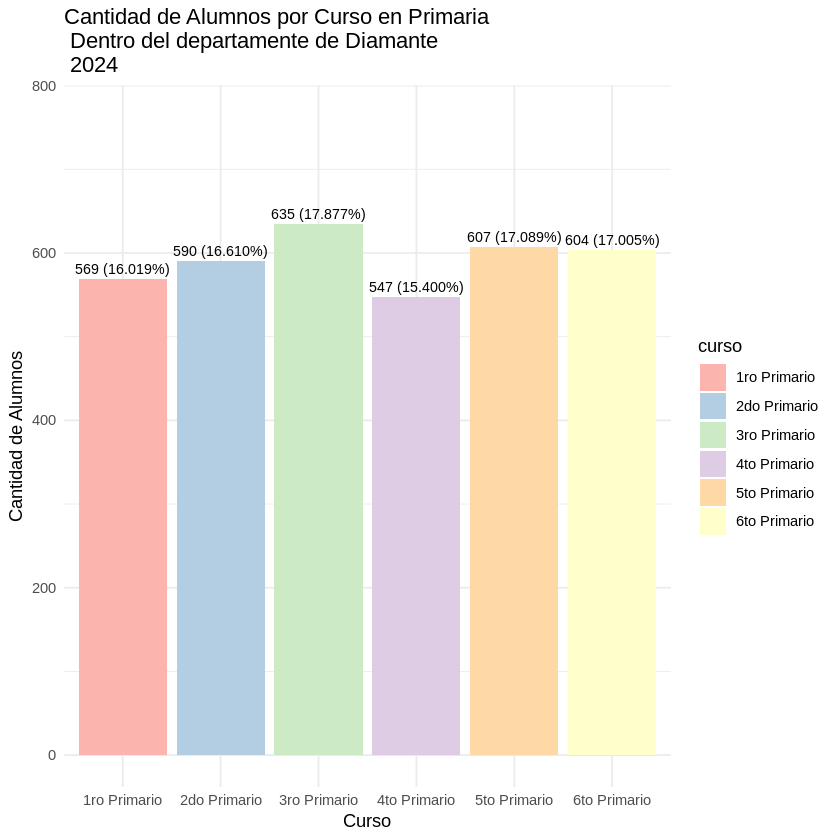

In [5]:
library(dplyr)  # Para manipulación de datos
library(ggplot2) # Para la creación de gráficos

# Calcular el total de estudiantes únicos
total_estudiantes <- df %>% distinct(Documento) %>% nrow()

# Agrupar por curso y calcular frecuencias
frecuencias <- df %>%
  distinct(Documento, curso) %>%
  group_by(curso) %>%
  summarise(
    Frecuencia_Absoluta = n(),
    Frecuencia_Relativa = n() / total_estudiantes # Dividir por el total de estudiantes únicos
  )

ggplot(frecuencias, aes(x = curso, y = Frecuencia_Absoluta, fill = curso)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = paste0(Frecuencia_Absoluta, " (", scales::percent(Frecuencia_Relativa), ")")),
            vjust = -0.5, size = 3) +
  labs(title = "Cantidad de Alumnos por Curso en Primaria \n Dentro del departamente de Diamante\n 2024 ",
       x = "Curso", y = "Cantidad de Alumnos") +
  theme_minimal() +
  scale_fill_brewer(palette = "Pastel1") +
  ylim(0, max(frecuencias$Frecuencia_Absoluta) * 1.2) # Ajusta este valor



In [6]:
library(readxl)
library(dplyr)



# Asegúrate de que la variable 'curso' sea un factor
if ("curso" %in% colnames(df)) {
  df_sin_outliers$curso <- as.factor(df_sin_outliers$curso)
} else {
  stop("La columna 'curso' no se encuentra en el dataframe.")
}

# Crear la tabla de frecuencia de estudiantes únicos por curso.
# Primero, obtenemos las combinaciones únicas de Documento y curso,
# luego contamos cuántos estudiantes únicos hay en cada curso.
tabla_frecuencia_curso_unicos <- df_sin_outliers %>%
  distinct(Documento, curso) %>% # Obtener combinaciones únicas de Documento y curso
  count(curso, name = "Frecuencia") # Contar cuántos estudiantes únicos hay por curso

# Mostrar la tabla de frecuencia de estudiantes únicos
print("Tabla de Frecuencia de Estudiantes Únicos por Curso:")
print(tabla_frecuencia_curso_unicos)

# Para realizar un test de Chi-cuadrado de bondad de ajuste con estudiantes únicos,
# necesitamos comparar las frecuencias observadas de estudiantes únicos por curso
# con las frecuencias esperadas si la distribución fuera uniforme.
total_estudiantes_unicos <- sum(tabla_frecuencia_curso_unicos$Frecuencia)
n_cursos <- nrow(tabla_frecuencia_curso_unicos)
frecuencia_esperada_uniforme <- total_estudiantes_unicos / n_cursos

# Creamos un vector con las frecuencias esperadas para cada curso (estudiantes únicos)
frecuencias_esperadas_unicos <- rep(frecuencia_esperada_uniforme, n_cursos)

# Realizar el test de Chi-cuadrado de bondad de ajuste con estudiantes únicos
cat("\n--- Resultados del Test de Chi-cuadrado de Bondad de Ajuste para Estudiantes Únicos (vs. distribución uniforme) ---\n")
# Solo realizar la prueba si hay suficientes datos y si las frecuencias esperadas no son cero
if (total_estudiantes_unicos > 0 && all(frecuencias_esperadas_unicos > 0)) {
  chisq.test(tabla_frecuencia_curso_unicos$Frecuencia, p = frecuencias_esperadas_unicos / total_estudiantes_unicos) # Usar probabilidades esperadas
} else {
  cat("No hay suficientes datos o las frecuencias esperadas son cero para realizar el test de Chi-cuadrado con estudiantes únicos.\n")
}

cat("\nInterpretación del Test de Chi-cuadrado de Bondad de Ajuste para Estudiantes Únicos:\n")
cat("- El p-valor (Pr(>X²)) te indica la probabilidad de observar una distribución de estudiantes únicos tan extrema o más extrema\n")
cat("  que la observada, si la distribución real de estudiantes por curso fuera uniforme (hipótesis nula).\n")
cat("- Si el p-valor es menor que tu nivel de significancia (comúnmente 0.05),\n")
cat("  rechazas la hipótesis nula. Esto significa que la distribución de estudiantes únicos por curso observada\n")
cat("  difiere significativamente de una distribución uniforme.\n")
cat("- Si el p-valor es mayor que 0.05, no hay evidencia suficiente para concluir que\n")
cat("  la distribución de estudiantes únicos difiere significativamente de una distribución uniforme.\n")

[1] "Tabla de Frecuencia de Estudiantes Únicos por Curso:"
# A tibble: 6 × 2
  curso        Frecuencia
  <fct>             <int>
1 1ro Primario        566
2 2do Primario        590
3 3ro Primario        635
4 4to Primario        547
5 5to Primario        605
6 6to Primario        601

--- Resultados del Test de Chi-cuadrado de Bondad de Ajuste para Estudiantes Únicos (vs. distribución uniforme) ---



	Chi-squared test for given probabilities

data:  tabla_frecuencia_curso_unicos$Frecuencia
X-squared = 8.1151, df = 5, p-value = 0.15



Interpretación del Test de Chi-cuadrado de Bondad de Ajuste para Estudiantes Únicos:
- El p-valor (Pr(>X²)) te indica la probabilidad de observar una distribución de estudiantes únicos tan extrema o más extrema
  que la observada, si la distribución real de estudiantes por curso fuera uniforme (hipótesis nula).
- Si el p-valor es menor que tu nivel de significancia (comúnmente 0.05),
  rechazas la hipótesis nula. Esto significa que la distribución de estudiantes únicos por curso observada
  difiere significativamente de una distribución uniforme.
- Si el p-valor es mayor que 0.05, no hay evidencia suficiente para concluir que
  la distribución de estudiantes únicos difiere significativamente de una distribución uniforme.


In [7]:
# Tabla de frecuencia de aprobados

library(dplyr)

tabla_frecuencias <- df %>%
  distinct(Documento, .keep_all = TRUE) %>%  # Mantener solo la primera aparición de cada documento
  count(EsPrivada) %>%  # Contar la frecuencia de EsPrivada
  mutate(
    Frecuencia_Relativa = n / sum(n),
    Frecuencia_Relativa_Acumulada = cumsum(Frecuencia_Relativa),
    Frecuencia_Porcentual = Frecuencia_Relativa * 100,
    Frecuencia_Porcentual_Acumulada = cumsum(Frecuencia_Porcentual)
  )

print(tabla_frecuencias)



# A tibble: 2 × 6
  EsPrivada     n Frecuencia_Relativa Frecuencia_Relativa_Acumulada
  <chr>     <int>               <dbl>                         <dbl>
1 N          2155               0.607                         0.607
2 S          1397               0.393                         1    
# ℹ 2 more variables: Frecuencia_Porcentual <dbl>,
#   Frecuencia_Porcentual_Acumulada <dbl>


Tabla de frecuencias por institucion


Loading required package: patchwork

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘patchwork’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



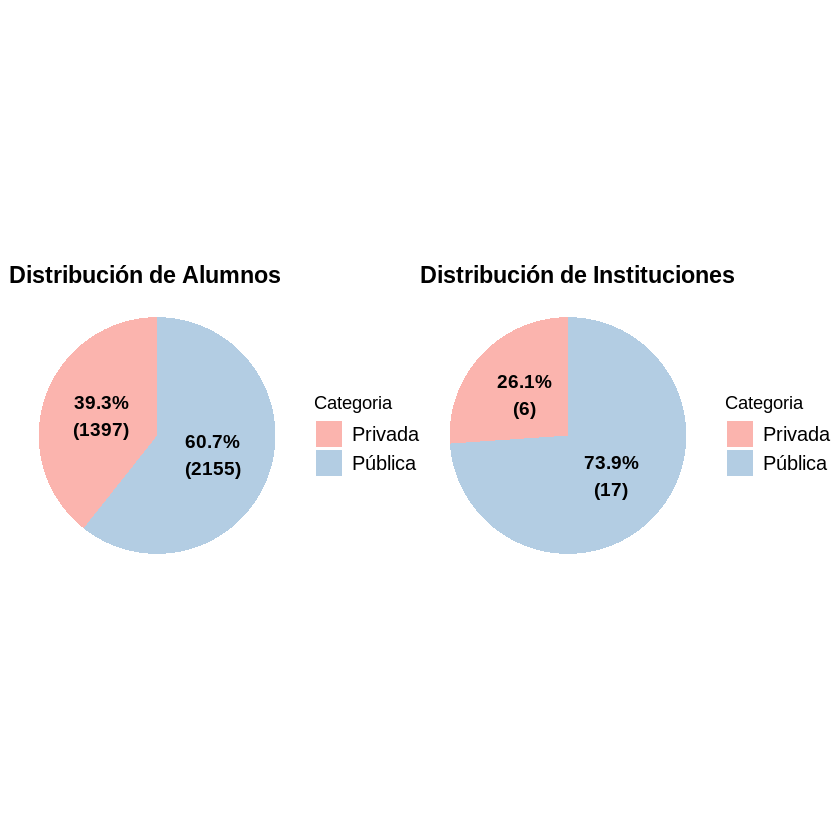

In [8]:
# Instalar y cargar la librería 'patchwork' si es necesario
if (!require("patchwork")) install.packages("patchwork")
library(patchwork)

# Cargar las librerías necesarias
library(ggplot2)
library(dplyr)

# --- Gráfico 1: Distribución de Alumnos ---

# 1. Calcular los datos para el gráfico de alumnos
data_alumnos <- df %>%
  distinct(Documento, EsPrivada) %>%
  count(EsPrivada) %>%
  mutate(
    Categoria = ifelse(EsPrivada == "S", "Privada", "Pública"),
    Frecuencia = n / sum(n)
  ) %>%
  select(Categoria, Frecuencia, n)

# 2. Crear el gráfico circular para alumnos
grafico_alumnos <- ggplot(data_alumnos, aes(x = "", y = Frecuencia, fill = Categoria)) +
  geom_bar(width = 1, stat = "identity") +
  coord_polar("y", start = 0) +
  geom_text(aes(label = paste0(round(Frecuencia * 100, 1), "%", "\n(", n, ")")),
            position = position_stack(vjust = 0.5), size = 4, fontface = "bold", color = "black") + # Tamaño de texto ajustado
  scale_fill_brewer(palette = "Pastel1") +
  labs(title = "Distribución de Alumnos", x = NULL, y = NULL) +
  theme_void() +
  theme(
    plot.title = element_text(size = 14, face = "bold"), # Tamaño de título ajustado
    legend.text = element_text(size = 12) # Tamaño de leyenda ajustado
  )


# --- Gráfico 2: Distribución de Instituciones ---

# 1. Calcular los datos para el gráfico de instituciones
data_instituciones <- df %>%
  distinct(institucion, EsPrivada) %>%
  count(EsPrivada) %>%
  mutate(
    Categoria = ifelse(EsPrivada == "S", "Privada", "Pública"),
    Frecuencia = n / sum(n)
  ) %>%
  select(Categoria, Frecuencia, n)

# 2. Crear el gráfico circular para instituciones
grafico_instituciones <- ggplot(data_instituciones, aes(x = "", y = Frecuencia, fill = Categoria)) +
  geom_bar(width = 1, stat = "identity") +
  coord_polar("y", start = 0) +
  geom_text(aes(label = paste0(round(Frecuencia * 100, 1), "%", "\n(", n, ")")),
            position = position_stack(vjust = 0.5), size = 4, fontface = "bold", color = "black") + # Tamaño de texto ajustado
  scale_fill_brewer(palette = "Pastel1") +
  labs(title = "Distribución de Instituciones", x = NULL, y = NULL) +
  theme_void() +
  theme(
    plot.title = element_text(size = 14, face = "bold"), # Tamaño de título ajustado
    legend.text = element_text(size = 12) # Tamaño de leyenda ajustado
  )

# --- Combinar los gráficos horizontalmente ---

grafico_combinado <- grafico_alumnos + grafico_instituciones

# Mostrar el gráfico combinado
print(grafico_combinado)

In [9]:
library("dplyr")

tabla_frecuencias <- df %>%
  distinct(Documento, institucion, .keep_all = TRUE) %>%
  count(institucion) %>%
  rename(Frecuencia_Absoluta = n) %>%
  mutate(
    Frecuencia_Relativa = Frecuencia_Absoluta / sum(Frecuencia_Absoluta),
    Frecuencia_Relativa_Acumulada = cumsum(Frecuencia_Relativa),
    Frecuencia_Porcentual = Frecuencia_Relativa * 100,
    Frecuencia_Porcentual_Acumulada = cumsum(Frecuencia_Porcentual),
    Frecuencia_Absoluta_Acumulada = cumsum(Frecuencia_Absoluta) # Calcular Frecuencia_Absoluta_Acumulada
  ) %>%
  arrange(Frecuencia_Absoluta_Acumulada) %>%
  select(institucion, Frecuencia_Absoluta_Acumulada, everything()) # Reordenar las columnas


View(tabla_frecuencias)


institucion,Frecuencia_Absoluta_Acumulada,Frecuencia_Absoluta,Frecuencia_Relativa,Frecuencia_Relativa_Acumulada,Frecuencia_Porcentual,Frecuencia_Porcentual_Acumulada
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
AGUSTIN DE LA TIJERA 23 - PRIMARIO,4,4,0.001126126,0.001126126,0.1126126,0.1126126
ALMAFUERTE 11 - PRIMARIO,55,51,0.014358108,0.015484234,1.4358108,1.5484234
ALVAREZ DE ARENALES 3 - PRIMARIO,112,57,0.016047297,0.031531532,1.6047297,3.1531532
ANTARTIDA ARGENTINA 6 - PRIMARIO,123,11,0.003096847,0.034628378,0.3096847,3.4628378
BDIER. GENERAL J.J.DE URQUIZA 9 - PRIMARIO,230,107,0.030123874,0.064752252,3.0123874,6.4752252
BLANCO ENCALADA 13 - PRIMARIO,284,54,0.015202703,0.079954955,1.5202703,7.9954955
CAPITAN DE NAVIO FELIX DUFOURQ 52 - PRIMARIO,397,113,0.031813063,0.111768018,3.1813063,11.1768018
ESCUELA PRIMARIA Nº 58 EMILIO HALLAM,417,20,0.005630631,0.117398649,0.5630631,11.7398649
GOBERNADOR ETCHEVEHERE 29 - PRIMARIO,673,256,0.072072072,0.189470721,7.2072072,18.9470721


In [10]:
tabla_frecuencias <- df %>%
  count(Aprobado) %>%
  mutate(
    Frecuencia_Relativa = n / sum(n),
    Frecuencia_Relativa_Acumulada = cumsum(Frecuencia_Relativa),
    Frecuencia_Porcentual = Frecuencia_Relativa * 100,
    Frecuencia_Porcentual_Acumulada = cumsum(Frecuencia_Porcentual)
  )
  print(tabla_frecuencias)

# A tibble: 2 × 6
  Aprobado        n Frecuencia_Relativa Frecuencia_Relativa_Acumulada
  <chr>       <int>               <dbl>                         <dbl>
1 Aprobado    27122              0.954                          0.954
2 No Aprobado  1294              0.0455                         1    
# ℹ 2 more variables: Frecuencia_Porcentual <dbl>,
#   Frecuencia_Porcentual_Acumulada <dbl>


In [11]:
library(dplyr)

# Definir el número de intervalos deseados
num_intervalos <- seq(0, 10, by = 2)

# Crear la tabla de frecuencia por intervalos para la variable 'promedio'
tabla_frecuencias_intervalos <- df %>%
  mutate(Intervalo = cut(promedio, breaks = num_intervalos)) %>%
  group_by(Intervalo) %>%
  summarise(Frecuencia = n()) %>%
  mutate(
    Frecuencia_Absoluta_Acumulada = cumsum(Frecuencia),
    Frecuencia_Relativa = round(Frecuencia / sum(Frecuencia), 4),
    Frecuencia_Relativa_Acumulada = cumsum(Frecuencia_Relativa),
    Frecuencia_Porcentual = Frecuencia_Relativa * 100,
    Frecuencia_Porcentual_Acumulada = cumsum(Frecuencia_Porcentual)
  )

# Mostrar la tabla
View(tabla_frecuencias_intervalos)

Intervalo,Frecuencia,Frecuencia_Absoluta_Acumulada,Frecuencia_Relativa,Frecuencia_Relativa_Acumulada,Frecuencia_Porcentual,Frecuencia_Porcentual_Acumulada
<fct>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
"(0,2]",297,297,0.0105,0.0105,1.05,1.05
"(2,4]",349,646,0.0123,0.0228,1.23,2.28
"(4,6]",1353,1999,0.0476,0.0704,4.76,7.04
"(6,8]",10939,12938,0.3850,0.4554,38.50,45.54
"(8,10]",15478,28416,0.5447,1.0001,54.47,100.01


In [12]:
# Instalar paquetes si es necesario
install.packages("DescTools")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘proxy’, ‘rootSolve’, ‘e1071’, ‘lmom’, ‘mvtnorm’, ‘expm’, ‘Exact’, ‘gld’




In [13]:
library(dplyr)
library(DescTools) # Para calcular la moda


calcular_estadisticas <- function(df, asignatura) {
  df %>%
    filter(Asignatura == asignatura) %>%
    group_by(curso) %>%
    summarise(
      Media = mean(promedio, na.rm = TRUE),
      Mediana = median(promedio, na.rm = TRUE),
      Moda = Mode(promedio, na.rm = TRUE)[1] # Toma la primera moda en caso de multimodalidad
    )
}

# Calcular estadísticas para Matemática
estadisticas_matematica <- calcular_estadisticas(df, "Matematica")

# Calcular estadísticas para Lengua
estadisticas_lengua <- calcular_estadisticas(df, "Lengua")

# Mostrar los resultados
print("Estadísticas para Matemática por Curso:")
print(estadisticas_matematica)

print("Estadísticas para Lengua por Curso:")
print(estadisticas_lengua)

[1] "Estadísticas para Matemática por Curso:"
# A tibble: 6 × 4
  curso        Media Mediana  Moda
  <chr>        <dbl>   <dbl> <dbl>
1 1ro Primario  7.52       8     9
2 2do Primario  7.45       8     9
3 3ro Primario  7.48       8     8
4 4to Primario  7.70       8     8
5 5to Primario  7.57       8     9
6 6to Primario  7.35       8     8
[1] "Estadísticas para Lengua por Curso:"
# A tibble: 6 × 4
  curso        Media Mediana  Moda
  <chr>        <dbl>   <dbl> <dbl>
1 1ro Primario  7.27       8     8
2 2do Primario  7.29       8     9
3 3ro Primario  7.37       8     8
4 4to Primario  7.62       8     8
5 5to Primario  7.50       8     8
6 6to Primario  7.57       8     8


In [14]:
library(dplyr)

# Filtrar los datos para la asignatura "lengua" y matematica
df_lengua <- df %>%
  filter(curso == "1ro Primario") %>%
  filter(Asignatura == "Lengua")

df_matematica <- df %>%
  filter(curso == "1ro Primario" & Asignatura == "Matematica") # Corrected line

# Definir los intervalos
intervalos <- seq(0,  10, by = 2)

# Crear la tabla de frecuencia por intervalos para la variable 'promedio'
tabla_frecuencias_intervalos_lengua <- df_lengua %>%
  mutate(Intervalo = cut(promedio, breaks = intervalos, include.lowest = TRUE)) %>%
  group_by(Intervalo) %>%
  summarise(Frecuencia = n()) %>%
  mutate(
    Frecuencia_Absoluta_Acumulada_lengua = cumsum(Frecuencia),
    Frecuencia_Relativa = round(Frecuencia / sum(Frecuencia), 4),
    Frecuencia_Relativa_Acumulada = cumsum(Frecuencia_Relativa),
    Frecuencia_Porcentual = Frecuencia_Relativa * 100,
    Frecuencia_Porcentual_Acumulada = cumsum(Frecuencia_Porcentual) # Agregar esta línea
  )

tabla_frecuencias_intervalos_matematica <- df_matematica %>%
  mutate(Intervalo = cut(promedio, breaks = intervalos, include.lowest = TRUE)) %>%
  group_by(Intervalo) %>%
  summarise(Frecuencia = n()) %>%
  mutate(
    Frecuencia_Absoluta_Acumulada = cumsum(Frecuencia),
    Frecuencia_Relativa = round(Frecuencia / sum(Frecuencia), 4),
    Frecuencia_Relativa_Acumulada = cumsum(Frecuencia_Relativa),
    Frecuencia_Porcentual = Frecuencia_Relativa * 100,
    Frecuencia_Porcentual_Acumulada = cumsum(Frecuencia_Porcentual) # Agregar esta línea
  )
# Mostrar la tabla
View(tabla_frecuencias_intervalos_lengua)
View(tabla_frecuencias_intervalos_matematica)



Intervalo,Frecuencia,Frecuencia_Absoluta_Acumulada_lengua,Frecuencia_Relativa,Frecuencia_Relativa_Acumulada,Frecuencia_Porcentual,Frecuencia_Porcentual_Acumulada
<fct>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
"[0,2]",25,25,0.0439,0.0439,4.39,4.39
"(2,4]",32,57,0.0562,0.1001,5.62,10.01
"(4,6]",55,112,0.0967,0.1968,9.67,19.68
"(6,8]",219,331,0.3849,0.5817,38.49,58.17
"(8,10]",238,569,0.4183,1.0000,41.83,100.00


Intervalo,Frecuencia,Frecuencia_Absoluta_Acumulada,Frecuencia_Relativa,Frecuencia_Relativa_Acumulada,Frecuencia_Porcentual,Frecuencia_Porcentual_Acumulada
<fct>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
"[0,2]",24,24,0.0422,0.0422,4.22,4.22
"(2,4]",24,48,0.0422,0.0844,4.22,8.44
"(4,6]",41,89,0.0721,0.1565,7.21,15.65
"(6,8]",221,310,0.3884,0.5449,38.84,54.49
"(8,10]",259,569,0.4552,1.0001,45.52,100.01


In [15]:
library(dplyr)

# Calcular la desviación estándar por curso para Lengua
desviacion_estandar_lengua <- df %>%
  filter(Asignatura == "Lengua") %>%
  group_by(curso) %>%
  summarise(DesviacionEstandar = sd(promedio, na.rm = TRUE))

# Calcular la desviación estándar por curso para Matemática
desviacion_estandar_matematica <- df %>%
  filter(Asignatura == "Matematica") %>%
  group_by(curso) %>%
  summarise(DesviacionEstandar = sd(promedio, na.rm = TRUE))

# Imprimir los resultados con separación
cat("\nDesviación Estándar para Lengua por Curso:\n\n")
print(desviacion_estandar_lengua)
cat("\n----------------------------------------\n\n")

cat("\nDesviación Estándar para Matemática por Curso:\n\n")
print(desviacion_estandar_matematica)
cat("\n----------------------------------------\n\n")



Desviación Estándar para Lengua por Curso:

# A tibble: 6 × 2
  curso        DesviacionEstandar
  <chr>                     <dbl>
1 1ro Primario               2.22
2 2do Primario               2.36
3 3ro Primario               2.22
4 4to Primario               1.73
5 5to Primario               1.88
6 6to Primario               1.79

----------------------------------------


Desviación Estándar para Matemática por Curso:

# A tibble: 6 × 2
  curso        DesviacionEstandar
  <chr>                     <dbl>
1 1ro Primario               2.12
2 2do Primario               2.23
3 3ro Primario               2.15
4 4to Primario               1.70
5 5to Primario               1.86
6 6to Primario               2.13

----------------------------------------



alumnos de primaria 3552, sencundaria 2985

In [16]:
library(dplyr)

# Calcular porcentaje para escuelas privadas
porcentaje_privadas <- df %>%
  filter(EsPrivada == "S") %>%
  summarise(
    AlumnosMasDe8 = sum(promedio > 8, na.rm = TRUE),
    TotalAlumnos = n()
  ) %>%
  mutate(Porcentaje = (AlumnosMasDe8 / TotalAlumnos) * 100)

# Calcular porcentaje para escuelas públicas
porcentaje_publicas <- df %>%
  filter(EsPrivada == "N") %>%
  summarise(
    AlumnosMasDe8 = sum(promedio > 8, na.rm = TRUE),
    TotalAlumnos = n()
  ) %>%
  mutate(Porcentaje = (AlumnosMasDe8 / TotalAlumnos) * 100)

# Imprimir los resultados
print("Porcentaje de alumnos con más de 8 en escuelas privadas:")
print(porcentaje_privadas$Porcentaje)

print("\nPorcentaje de alumnos con más de 8 en escuelas públicas:")
print(porcentaje_publicas$Porcentaje)

[1] "Porcentaje de alumnos con más de 8 en escuelas privadas:"
[1] 68.32498
[1] "\nPorcentaje de alumnos con más de 8 en escuelas públicas:"
[1] 45.48724


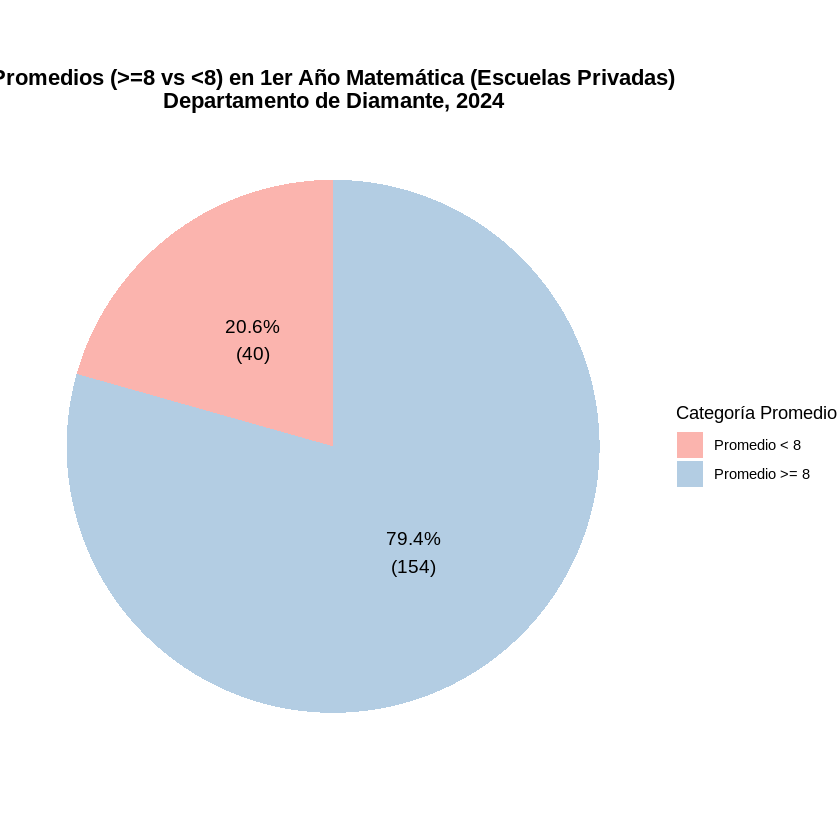

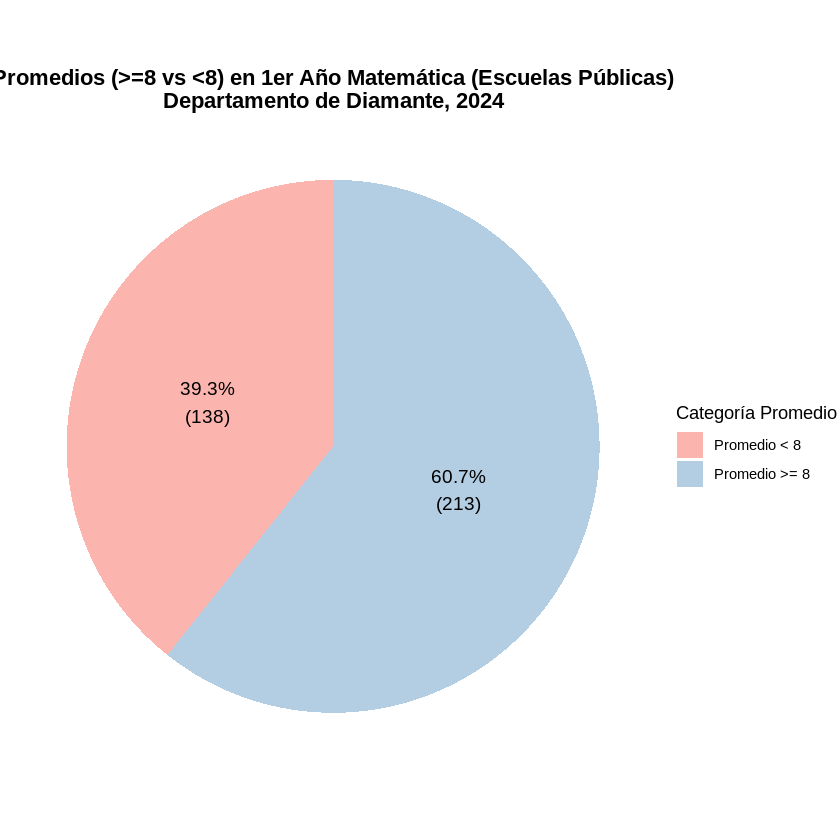

In [17]:
library(dplyr)
library(ggplot2)
library(scales) # Para formatear porcentajes en las etiquetas
library(tidyr) # Necesario para pivot_longer si no lo has usado recientemente en la sesión
# library(patchwork) # Opcional: para combinar los dos gráficos si quieres mostrarlos juntos

# Asegúrate de que df_sin_outliers esté cargado y tenga la columna 'promedio'.

# --- Preparación de Datos ---

# Filtrar datos para alumnos de primer año en Matemática (sin outliers)
df_1ro_matematica <- df_sin_outliers %>%
  filter(curso == "3ro Primario", Asignatura == "Matematica") %>%
  drop_na(promedio) # Eliminar alumnos sin promedio

# Crear la variable de categoría de promedio y preparar datos para el gráfico
data_graficos_torta <- df_1ro_matematica %>%
  mutate(
    CategoriaPromedio = case_when(
      promedio >= 8 ~ "Promedio >= 8",
      promedio < 8 ~ "Promedio < 8",
      TRUE ~ "Otros" # Por si acaso, aunque drop_na(promedio) debería prevenir esto
    ),
    TipoEscuela = ifelse(EsPrivada == "S", "Privada", "Pública")
  ) %>%
  filter(CategoriaPromedio != "Otros") %>% # Eliminar la categoría "Otros" si no es necesaria
  group_by(TipoEscuela, CategoriaPromedio) %>%
  summarise(n = n(), .groups = 'drop') %>% # Contar por grupo y soltar la agrupación
  group_by(TipoEscuela) %>% # Agrupar de nuevo por tipo de escuela para calcular porcentajes dentro de cada tipo
  mutate(Porcentaje = n / sum(n)) %>%
  ungroup() # Quitar la agrupación final


# --- Crear Gráfico de Torta para Escuelas Privadas ---

# Filtrar los datos solo para Privadas
data_torta_privadas <- data_graficos_torta %>%
  filter(TipoEscuela == "Privada")

# Verificar si hay datos para escuelas privadas antes de graficar
if(nrow(data_torta_privadas) > 0) {
  grafico_torta_privadas <- ggplot(data_torta_privadas, aes(x = "", y = Porcentaje, fill = CategoriaPromedio)) +
    geom_bar(width = 1, stat = "identity") +
    coord_polar("y", start = 0) + # Convertir a gráfico de torta
    geom_text(aes(label = paste0(round(Porcentaje * 100, 1), "%\n(", n, ")")), # Etiquetas con porcentaje y conteo
              position = position_stack(vjust = 0.5),
              color = "black", size = 4) + # Ajusta tamaño y color del texto si es necesario
    scale_fill_brewer(palette = "Pastel1") + # O elige otra paleta
    labs(title =   "Promedios (>=8 vs <8) en 1er Año Matemática (Escuelas Privadas)\nDepartamento de Diamante, 2024",
         x = NULL, y = NULL, fill = "Categoría Promedio") +
    theme_void() + # Quitar ejes y fondo no relevantes
    theme(plot.title = element_text(hjust = 0.5, face = "bold")) # Centrar título

  # Mostrar el gráfico de torta para privadas
  print(grafico_torta_privadas)
} else {
  cat("No hay datos para crear el gráfico de torta de escuelas privadas.\n")
}


# --- Crear Gráfico de Torta para Escuelas Públicas ---

# Filtrar los datos solo para Públicas
data_torta_publicas <- data_graficos_torta %>%
  filter(TipoEscuela == "Pública")

# Verificar si hay datos para escuelas públicas antes de graficar
if(nrow(data_torta_publicas) > 0) {
  grafico_torta_publicas <- ggplot(data_torta_publicas, aes(x = "", y = Porcentaje, fill = CategoriaPromedio)) +
    geom_bar(width = 1, stat = "identity") +
    coord_polar("y", start = 0) + # Convertir a gráfico de torta
    geom_text(aes(label = paste0(round(Porcentaje * 100, 1), "%\n(", n, ")")), # Etiquetas con porcentaje y conteo
              position = position_stack(vjust = 0.5),
              color = "black", size = 4) + # Ajusta tamaño y color del texto
    scale_fill_brewer(palette = "Pastel1") + # O elige otra paleta
    labs(title =   "Promedios (>=8 vs <8) en 1er Año Matemática (Escuelas Públicas)\nDepartamento de Diamante, 2024",
         x = NULL, y = NULL, fill = "Categoría Promedio") +
    theme_void() + # Quitar ejes y fondo no relevantes
    theme(plot.title = element_text(hjust = 0.5, face = "bold")) # Centrar título

  # Mostrar el gráfico de torta para públicas
  print(grafico_torta_publicas)
} else {
  cat("No hay datos para crear el gráfico de torta de escuelas públicas.\n")
}


# --- Opcional: Combinar los gráficos si usas patchwork ---
# if (requireNamespace("patchwork", quietly = TRUE) &&
#     exists("grafico_torta_privadas") && !is.null(grafico_torta_privadas) &&
#     exists("grafico_torta_publicas") && !is.null(grafico_torta_publicas)) {
#   grafico_combinado_torta <- grafico_torta_privadas + grafico_torta_publicas
#   print(grafico_combinado_torta)
# }

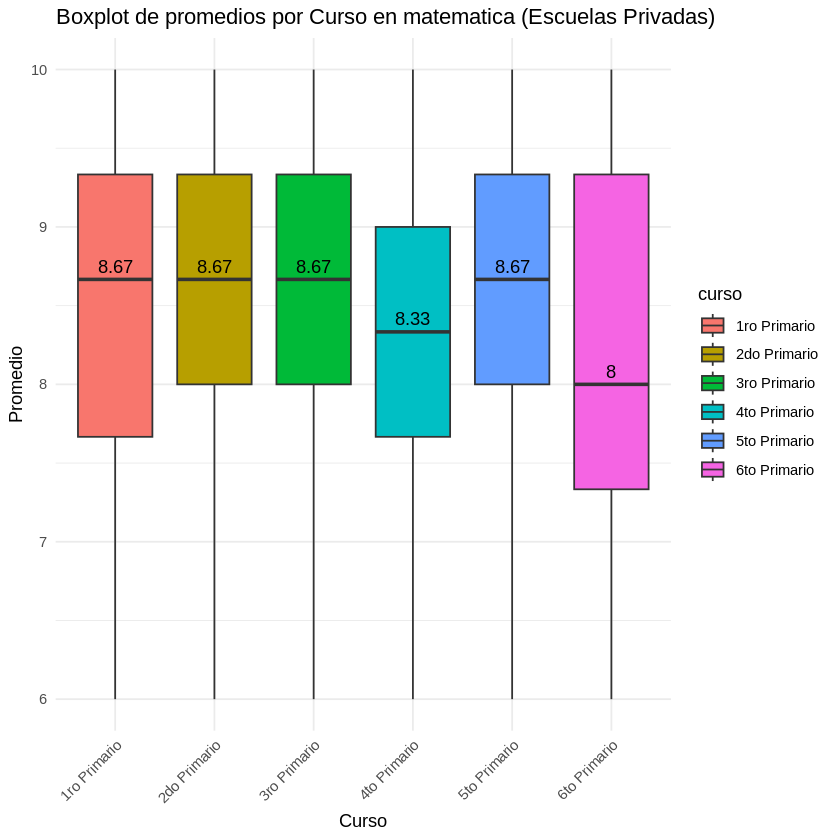

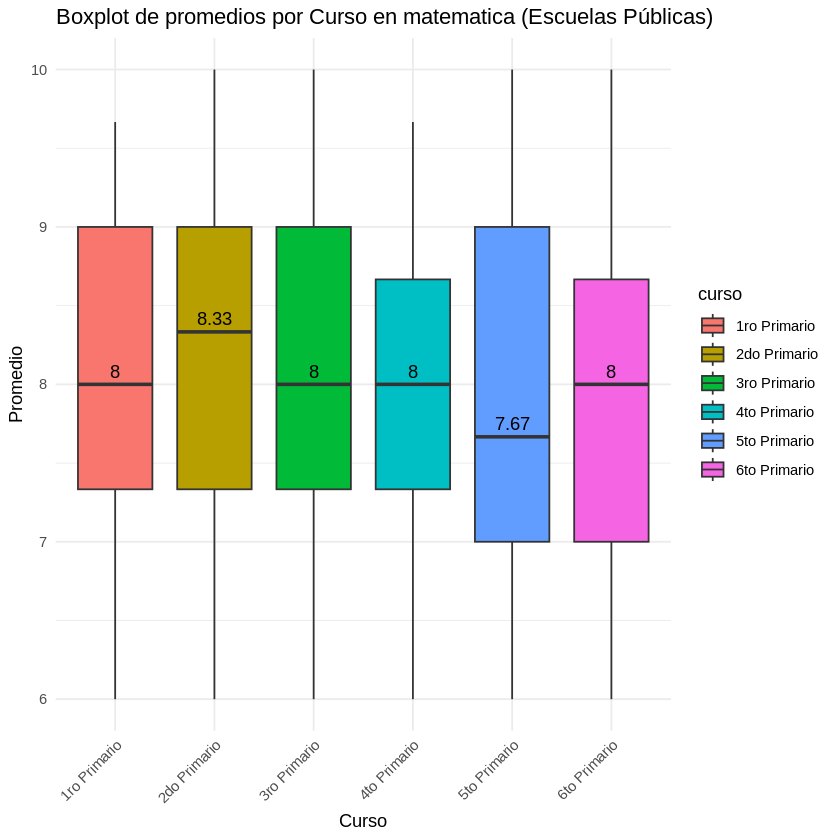

In [18]:
library(ggplot2)
library(dplyr)

# Filtrar los datos para escuelas privadas y matemática
df_privadas <- df %>%
  filter(EsPrivada == "S", Asignatura == "Matematica",
         NotaPrimerTrimestre > 1, NotaSegundoTrimestre > 1, NotaTercerTrimestre > 1)

# Calcular la mediana para cada curso en escuelas privadas
medianas_privadas <- df_privadas %>%
  group_by(curso) %>%
  summarise(mediana = median(promedio))

# Crear el boxplot por curso con la mediana para escuelas privadas
ggplot(df_privadas, aes(x = curso, y = promedio, fill = curso)) +
  geom_boxplot() +
  geom_text(data = medianas_privadas, aes(x = curso, y = mediana, label = round(mediana, 2)),
            vjust = -0.5, color = "black") +
  labs(title = "Boxplot de promedios por Curso en matematica (Escuelas Privadas)",
       x = "Curso",
       y = "Promedio") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))



# Filtrar los datos para escuelas públicas y matemática
df_publicas <- df %>%
  filter(EsPrivada == "N", Asignatura == "Matematica",
         NotaPrimerTrimestre > 1, NotaSegundoTrimestre > 1, NotaTercerTrimestre > 1)

# Calcular la mediana para cada curso en escuelas públicas
medianas_publicas <- df_publicas %>%
  group_by(curso) %>%
  summarise(mediana = median(promedio))

# Crear el boxplot por curso con la mediana para escuelas públicas
ggplot(df_publicas, aes(x = curso, y = promedio, fill = curso)) +
  geom_boxplot() +
  geom_text(data = medianas_publicas, aes(x = curso, y = mediana, label = round(mediana, 2)),
            vjust = -0.5, color = "black") +
  labs(title = "Boxplot de promedios por Curso en matematica (Escuelas Públicas)",
       x = "Curso",
       y = "Promedio") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))



Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_bar()`).”


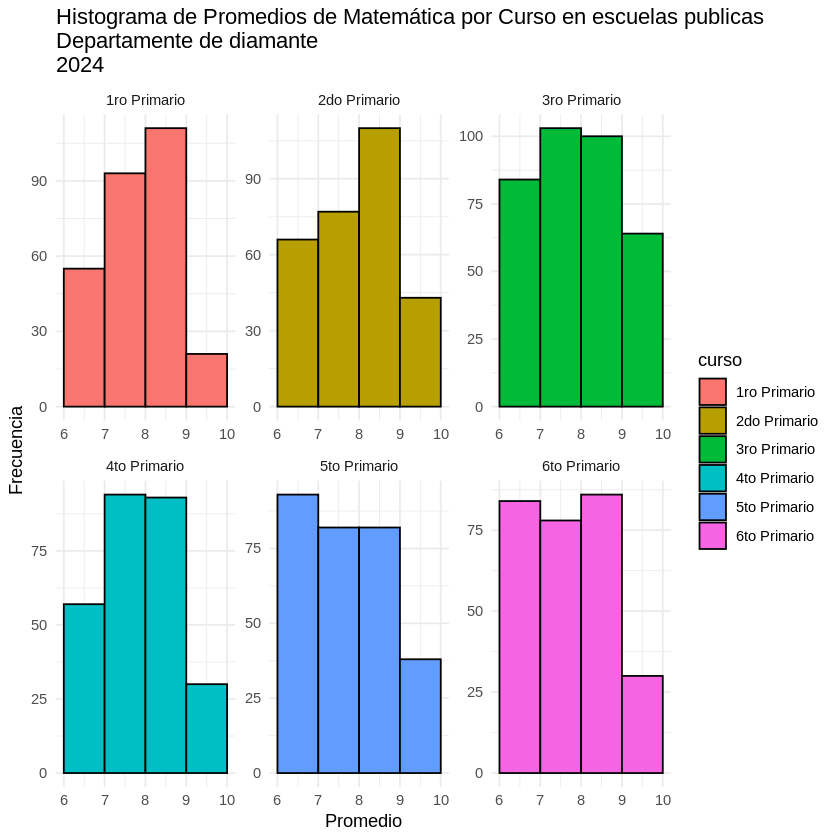

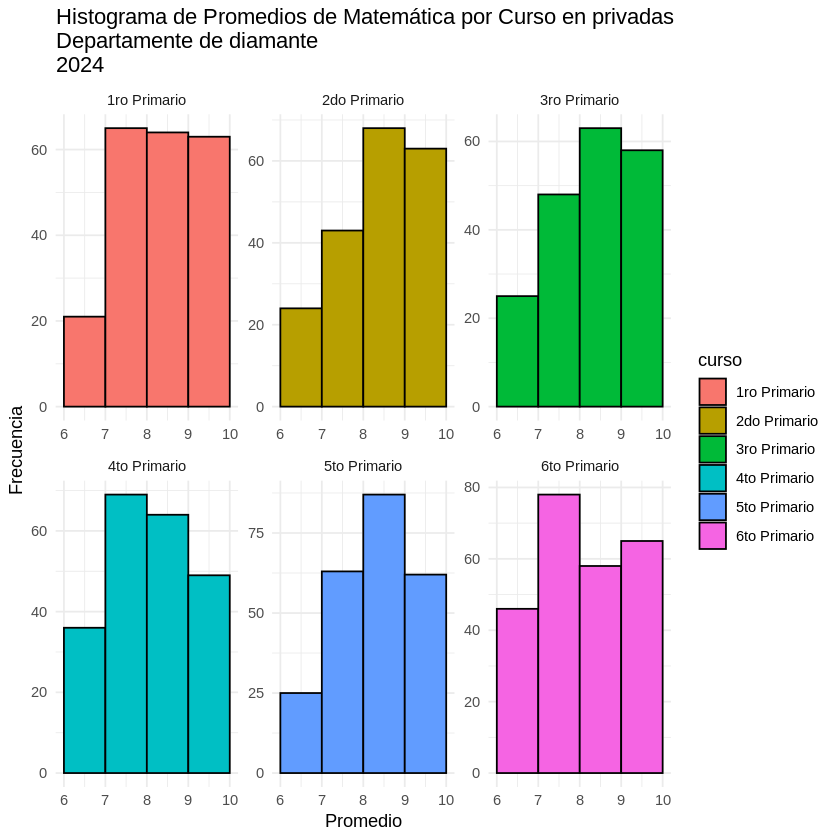

In [19]:
library(ggplot2)

# Filtrar los datos para escuelas públicas
df_publicas <- df_sin_outliers %>% filter(EsPrivada == "N", Asignatura == "Matematica")

library(ggplot2)

# Crear el histograma
ggplot(df_publicas, aes(x = promedio, fill = curso)) +  # O df_privadas, según corresponda
  geom_histogram(breaks = c(6, 7, 8, 9, 10, 11),  # Definir los intervalos para las barras
                 color = "black") +
  facet_wrap(~ curso, scales = "free") +
  labs(title = "Histograma de Promedios de Matemática por Curso en escuelas publicas\nDepartamente de diamante \n2024",
       x = "Promedio", y = "Frecuencia") +
  xlim(6, 10) + # Ajustar los límites del eje X
  theme_minimal()



# Filtrar los datos para escuelas privadas
df_privadas <- df_sin_outliers %>% filter(EsPrivada == "S", Asignatura == "Matematica")

# Crear el histograma para escuelas privadas
library(ggplot2)

# ... (código para filtrar datos para escuelas públicas o privadas)

# Crear el histograma
ggplot(df_privadas, aes(x = promedio, fill = curso)) +  # O df_privadas, según corresponda
  geom_histogram(breaks = c(6, 7, 8, 9, 10, 11),  # Definir los intervalos para las barras
                 color = "black") +
  facet_wrap(~ curso, scales = "free") +
  labs(title = "Histograma de Promedios de Matemática por Curso en privadas\nDepartamente de diamante \n2024",
       x = "Promedio", y = "Frecuencia") +
  xlim(6, 10) + # Ajustar los límites del eje X
  theme_minimal()



In [20]:
library(dplyr)

# Filtrar los datos para primer año de escuelas privadas y públicas en Matemática
Primero_matematica_priv <- df_sin_outliers %>% filter(Asignatura == "Matematica", curso == "1ro Primario", EsPrivada == "S")
Primero_matematica_pub <- df_sin_outliers %>% filter(Asignatura == "Matematica", curso == "1ro Primario", EsPrivada == "N")

# --- Prueba Kolmogorov-Smirnov para Normalidad (Un Sample) ---

# Para escuelas privadas
cat("Prueba Kolmogorov-Smirnov para Normalidad en escuelas privadas (Matemática):\n")
ks.test(Primero_matematica_priv$promedio, "pnorm", mean=mean(Primero_matematica_priv$promedio), sd=sd(Primero_matematica_priv$promedio))

# Para escuelas públicas
cat("\nPrueba Kolmogorov-Smirnov para Normalidad en escuelas públicas (Matemática):\n")
ks.test(Primero_matematica_pub$promedio, "pnorm", mean=mean(Primero_matematica_pub$promedio), sd=sd(Primero_matematica_pub$promedio))

# --- Prueba Kolmogorov-Smirnov de Dos Samples ---

# Comparar la distribución de los promedios entre escuelas privadas y públicas
cat("\nPrueba Kolmogorov-Smirnov de Dos Samples (Privadas vs. Públicas en Matemática):\n")
ks.test(Primero_matematica_priv$promedio, Primero_matematica_pub$promedio)

Prueba Kolmogorov-Smirnov para Normalidad en escuelas privadas (Matemática):


Warning message in ks.test.default(Primero_matematica_priv$promedio, "pnorm", mean = mean(Primero_matematica_priv$promedio), :
“ties should not be present for the one-sample Kolmogorov-Smirnov test”



	Asymptotic one-sample Kolmogorov-Smirnov test

data:  Primero_matematica_priv$promedio
D = 0.096403, p-value = 0.03816
alternative hypothesis: two-sided



Prueba Kolmogorov-Smirnov para Normalidad en escuelas públicas (Matemática):


Warning message in ks.test.default(Primero_matematica_pub$promedio, "pnorm", mean = mean(Primero_matematica_pub$promedio), :
“ties should not be present for the one-sample Kolmogorov-Smirnov test”



	Asymptotic one-sample Kolmogorov-Smirnov test

data:  Primero_matematica_pub$promedio
D = 0.13009, p-value = 0.0001533
alternative hypothesis: two-sided



Prueba Kolmogorov-Smirnov de Dos Samples (Privadas vs. Públicas en Matemática):


Warning message in ks.test.default(Primero_matematica_priv$promedio, Primero_matematica_pub$promedio):
“p-value will be approximate in the presence of ties”



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  Primero_matematica_priv$promedio and Primero_matematica_pub$promedio
D = 0.22077, p-value = 1.512e-05
alternative hypothesis: two-sided


In [21]:
library(dplyr)

# Filtrar los datos para primer año de escuelas privadas y públicas en Matemática
Primero_matematica_priv <- df_sin_outliers %>% filter(Asignatura == "Matematica", curso == "1ro Primario", EsPrivada == "S")
Primero_matematica_pub <- df_sin_outliers %>% filter(Asignatura == "Matematica", curso == "1ro Primario", EsPrivada == "N")

# Realizar la prueba U de Mann-Whitney (wilcox.test para datos independientes)
cat("Prueba U de Mann-Whitney (Privadas vs. Públicas en Matemática):\n")
wilcox.test(Primero_matematica_priv$promedio, Primero_matematica_pub$promedio, alternative = "greater")

Prueba U de Mann-Whitney (Privadas vs. Públicas en Matemática):



	Wilcoxon rank sum test with continuity correction

data:  Primero_matematica_priv$promedio and Primero_matematica_pub$promedio
W = 37224, p-value = 1.008e-06
alternative hypothesis: true location shift is greater than 0


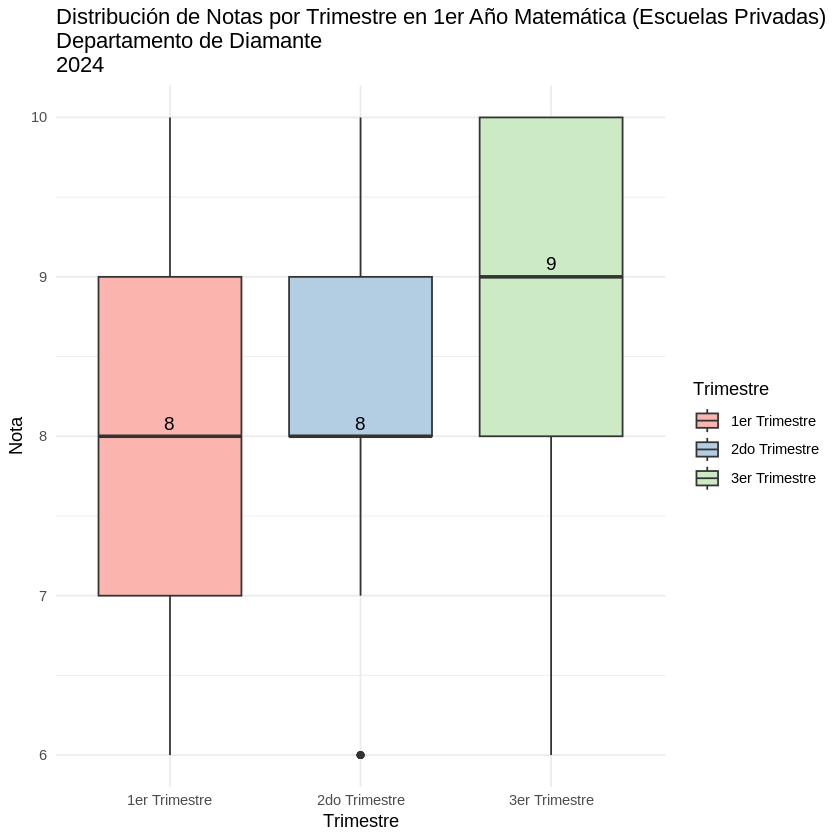

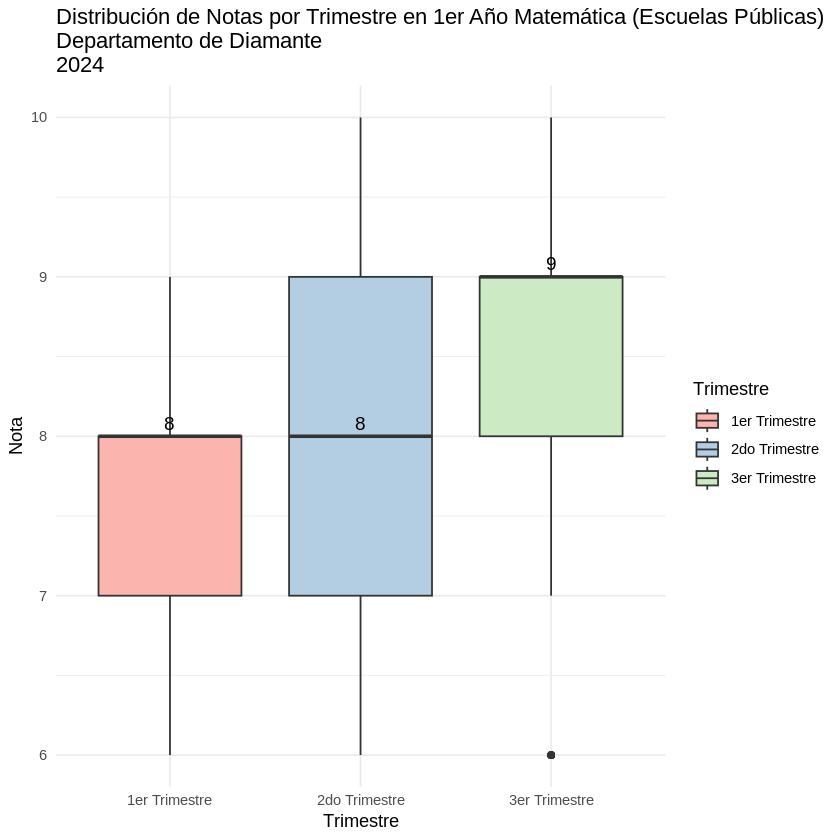

In [22]:
library(dplyr)
library(ggplot2)
library(tidyr) # Necesario para pivot_longer

# Asegúrate de que tu dataframe principal 'df' esté cargado.

# --- Escuelas Privadas ---

# 1. Filtrar los datos para primer año de escuelas privadas en Matemática
df_privadas_1ro_matematica <- df_sin_outliers %>%
  filter(curso == "1ro Primario", Asignatura == "Matematica", EsPrivada == "S") %>%
  select(Documento, NotaPrimerTrimestre, NotaSegundoTrimestre, NotaTercerTrimestre) %>%
  drop_na() # Eliminar filas con valores faltantes en las notas trimestrales

# Verificar si hay datos después del filtrado para escuelas privadas
if(nrow(df_privadas_1ro_matematica) == 0) {
  stop("No hay datos para alumnos de 1ro Primario en escuelas privadas de Matemática con notas completas para el boxplot.")
}

# 2. Transformar los datos a formato largo para escuelas privadas
df_largo_privadas <- df_privadas_1ro_matematica %>%
  pivot_longer(cols = starts_with("Nota"),
               names_to = "Trimestre",
               values_to = "Nota") %>%
  mutate(
    Trimestre = factor(Trimestre, levels = c("NotaPrimerTrimestre", "NotaSegundoTrimestre", "NotaTercerTrimestre"),
                       labels = c("1er Trimestre", "2do Trimestre", "3er Trimestre")) # Etiquetas más amigables
  )

# 3. Calcular las medianas por trimestre para escuelas privadas
medianas_trimestre_privadas <- df_largo_privadas %>%
  group_by(Trimestre) %>%
  summarise(mediana = median(Nota, na.rm = TRUE))

# 4. Crear el boxplot con las medianas para escuelas privadas
ggplot(df_largo_privadas, aes(x = Trimestre, y = Nota, fill = Trimestre)) +
  geom_boxplot() +
  geom_text(data = medianas_trimestre_privadas, aes(x = Trimestre, y = mediana, label = round(mediana, 2)),
            vjust = -0.5, color = "black", size = 4) + # Agregar etiquetas de mediana con tamaño ajustado
  labs(title = "Distribución de Notas por Trimestre en 1er Año Matemática (Escuelas Privadas)\nDepartamento de Diamante\n2024",
       x = "Trimestre",
       y = "Nota") +
  theme_minimal() +
  scale_fill_brewer(palette = "Pastel1") # O elige otra paleta de colores


# --- Escuelas Públicas ---

# 1. Filtrar los datos para primer año de escuelas públicas en Matemática
df_publicas_1ro_matematica <- df_sin_outliers %>%
  filter(curso == "1ro Primario", Asignatura == "Matematica", EsPrivada == "N") %>%
  select(Documento, NotaPrimerTrimestre, NotaSegundoTrimestre, NotaTercerTrimestre) %>%
  drop_na() # Eliminar filas con valores faltantes en las notas trimestrales

# Verificar si hay datos después del filtrado para escuelas públicas
if(nrow(df_publicas_1ro_matematica) == 0) {
  stop("No hay datos para alumnos de 1ro Primario en escuelas públicas de Matemática con notas completas para el boxplot.")
}

# 2. Transformar los datos a formato largo para escuelas públicas
df_largo_publicas <- df_publicas_1ro_matematica %>%
  pivot_longer(cols = starts_with("Nota"),
               names_to = "Trimestre",
               values_to = "Nota") %>%
  mutate(
    Trimestre = factor(Trimestre, levels = c("NotaPrimerTrimestre", "NotaSegundoTrimestre", "NotaTercerTrimestre"),
                       labels = c("1er Trimestre", "2do Trimestre", "3er Trimestre")) # Etiquetas más amigables
  )

# 3. Calcular las medianas por trimestre para escuelas públicas
medianas_trimestre_publicas <- df_largo_publicas %>%
  group_by(Trimestre) %>%
  summarise(mediana = median(Nota, na.rm = TRUE))

# 4. Crear el boxplot con las medianas para escuelas públicas
ggplot(df_largo_publicas, aes(x = Trimestre, y = Nota, fill = Trimestre)) +
  geom_boxplot() +
  geom_text(data = medianas_trimestre_publicas, aes(x = Trimestre, y = mediana, label = round(mediana, 2)),
            vjust = -0.5, color = "black", size = 4) + # Agregar etiquetas de mediana con tamaño ajustado
  labs(title = "Distribución de Notas por Trimestre en 1er Año Matemática (Escuelas Públicas)\nDepartamento de Diamante\n2024",
       x = "Trimestre",
       y = "Nota") +
  theme_minimal() +
  scale_fill_brewer(palette = "Pastel1") # O elige otra paleta de colores

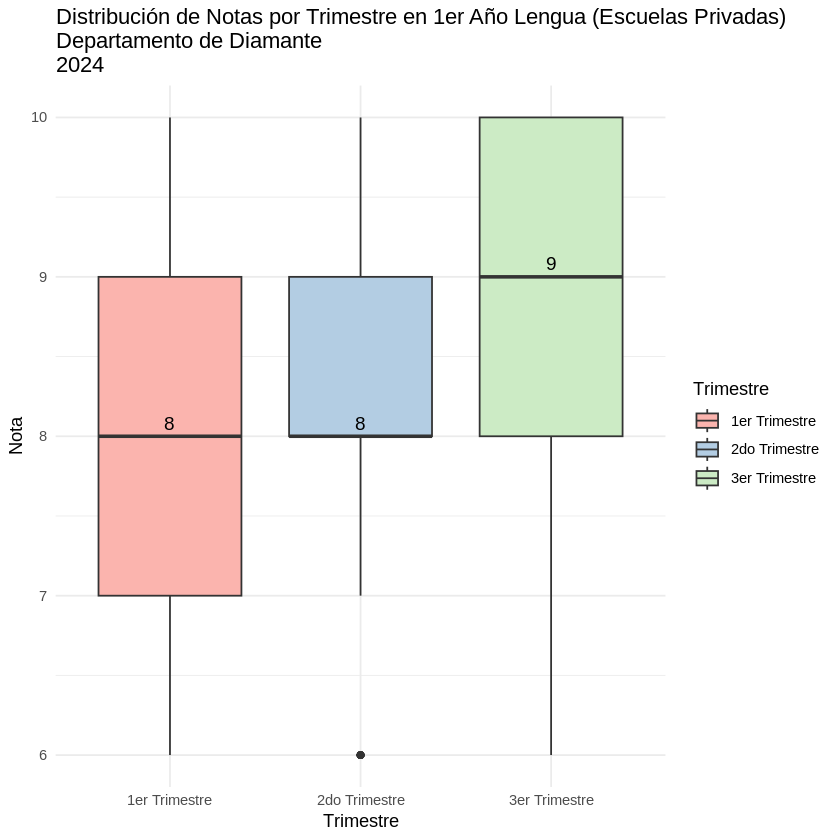

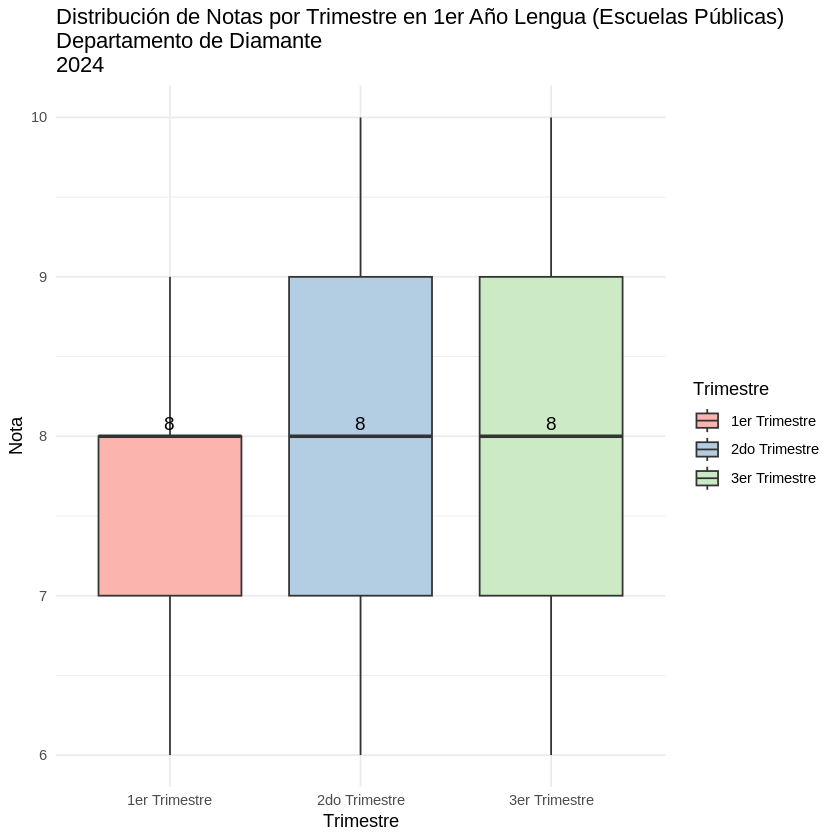

In [23]:
library(dplyr)
library(ggplot2)
library(tidyr) # Necesario para pivot_longer

# Asegúrate de que tu dataframe principal 'df' esté cargado.

# --- Escuelas Privadas ---

# 1. Filtrar los datos para primer año de escuelas privadas en Matemática
df_privadas_1ro_matematica <- df_sin_outliers %>%
  filter(curso == "1ro Primario", Asignatura == "Lengua", EsPrivada == "S") %>%
  select(Documento, NotaPrimerTrimestre, NotaSegundoTrimestre, NotaTercerTrimestre) %>%
  drop_na() # Eliminar filas con valores faltantes en las notas trimestrales

# Verificar si hay datos después del filtrado para escuelas privadas
if(nrow(df_privadas_1ro_matematica) == 0) {
  stop("No hay datos para alumnos de 1ro Primario en escuelas privadas de Matemática con notas completas para el boxplot.")
}

# 2. Transformar los datos a formato largo para escuelas privadas
df_largo_privadas <- df_privadas_1ro_matematica %>%
  pivot_longer(cols = starts_with("Nota"),
               names_to = "Trimestre",
               values_to = "Nota") %>%
  mutate(
    Trimestre = factor(Trimestre, levels = c("NotaPrimerTrimestre", "NotaSegundoTrimestre", "NotaTercerTrimestre"),
                       labels = c("1er Trimestre", "2do Trimestre", "3er Trimestre")) # Etiquetas más amigables
  )

# 3. Calcular las medianas por trimestre para escuelas privadas
medianas_trimestre_privadas <- df_largo_privadas %>%
  group_by(Trimestre) %>%
  summarise(mediana = median(Nota, na.rm = TRUE))

# 4. Crear el boxplot con las medianas para escuelas privadas
ggplot(df_largo_privadas, aes(x = Trimestre, y = Nota, fill = Trimestre)) +
  geom_boxplot() +
  geom_text(data = medianas_trimestre_privadas, aes(x = Trimestre, y = mediana, label = round(mediana, 2)),
            vjust = -0.5, color = "black", size = 4) + # Agregar etiquetas de mediana con tamaño ajustado
  labs(title = "Distribución de Notas por Trimestre en 1er Año Lengua (Escuelas Privadas)\nDepartamento de Diamante\n2024",
       x = "Trimestre",
       y = "Nota") +
  theme_minimal() +
  scale_fill_brewer(palette = "Pastel1") # O elige otra paleta de colores


# --- Escuelas Públicas ---

# 1. Filtrar los datos para primer año de escuelas públicas en Matemática
df_publicas_1ro_matematica <- df_sin_outliers %>%
  filter(curso == "1ro Primario", Asignatura == "Lengua", EsPrivada == "N") %>%
  select(Documento, NotaPrimerTrimestre, NotaSegundoTrimestre, NotaTercerTrimestre) %>%
  drop_na() # Eliminar filas con valores faltantes en las notas trimestrales

# Verificar si hay datos después del filtrado para escuelas públicas
if(nrow(df_publicas_1ro_matematica) == 0) {
  stop("No hay datos para alumnos de 1ro Primario en escuelas públicas de Matemática con notas completas para el boxplot.")
}

# 2. Transformar los datos a formato largo para escuelas públicas
df_largo_publicas <- df_publicas_1ro_matematica %>%
  pivot_longer(cols = starts_with("Nota"),
               names_to = "Trimestre",
               values_to = "Nota") %>%
  mutate(
    Trimestre = factor(Trimestre, levels = c("NotaPrimerTrimestre", "NotaSegundoTrimestre", "NotaTercerTrimestre"),
                       labels = c("1er Trimestre", "2do Trimestre", "3er Trimestre")) # Etiquetas más amigables
  )

# 3. Calcular las medianas por trimestre para escuelas públicas
medianas_trimestre_publicas <- df_largo_publicas %>%
  group_by(Trimestre) %>%
  summarise(mediana = median(Nota, na.rm = TRUE))

# 4. Crear el boxplot con las medianas para escuelas públicas
ggplot(df_largo_publicas, aes(x = Trimestre, y = Nota, fill = Trimestre)) +
  geom_boxplot() +
  geom_text(data = medianas_trimestre_publicas, aes(x = Trimestre, y = mediana, label = round(mediana, 2)),
            vjust = -0.5, color = "black", size = 4) + # Agregar etiquetas de mediana con tamaño ajustado
  labs(title = "Distribución de Notas por Trimestre en 1er Año Lengua (Escuelas Públicas)\nDepartamento de Diamante\n2024",
       x = "Trimestre",
       y = "Nota") +
  theme_minimal() +
  scale_fill_brewer(palette = "Pastel1") # O elige otra paleta de colores

In [24]:
# Para escuelas privadas
    cat("--- Verificación de Normalidad (Shapiro-Wilk) por Trimestre (Escuelas Privadas) ---\n")
    shapiro_primer_priv <- try(shapiro.test(df_privadas_1ro_matematica$NotaPrimerTrimestre), silent = TRUE)
    shapiro_segundo_priv <- try(shapiro.test(df_privadas_1ro_matematica$NotaSegundoTrimestre), silent = TRUE)
    shapiro_tercer_priv <- try(shapiro.test(df_privadas_1ro_matematica$NotaTercerTrimestre), silent = TRUE)

    if(class(shapiro_primer_priv) != "try-error") print("NotaPrimerTrimestre (Privadas):"); if(class(shapiro_primer_priv) != "try-error") print(shapiro_primer_priv)
    if(class(shapiro_segundo_priv) != "try-error") print("\nNotaSegundoTrimestre (Privadas):"); if(class(shapiro_segundo_priv) != "try-error") print(shapiro_segundo_priv)
    if(class(shapiro_tercer_priv) != "try-error") print("\nNotaTercerTrimestre (Privadas):"); if(class(shapiro_tercer_priv) != "try-error") print(shapiro_tercer_priv)

    # Para escuelas públicas
    cat("\n--- Verificación de Normalidad (Shapiro-Wilk) por Trimestre (Escuelas Públicas) ---\n")
    shapiro_primer_pub <- try(shapiro.test(df_publicas_1ro_matematica$NotaPrimerTrimestre), silent = TRUE)
    shapiro_segundo_pub <- try(shapiro.test(df_publicas_1ro_matematica$NotaSegundoTrimestre), silent = TRUE)
    shapiro_tercer_pub <- try(shapiro.test(df_publicas_1ro_matematica$NotaTercerTrimestre), silent = TRUE)

    if(class(shapiro_primer_pub) != "try-error") print("NotaPrimerTrimestre (Públicas):"); if(class(shapiro_primer_pub) != "try-error") print(shapiro_primer_pub)
    if(class(shapiro_segundo_pub) != "try-error") print("\nNotaSegundoTrimestre (Públicas):"); if(class(shapiro_segundo_pub) != "try-error") print(shapiro_segundo_pub)
    if(class(shapiro_tercer_pub) != "try-error") print("\nNotaTercerTrimestre (Públicas):"); if(class(shapiro_tercer_pub) != "try-error") print(shapiro_tercer_pub)

    cat("\nNota: Un p-valor bajo (< 0.05) sugiere no normalidad.\n")

--- Verificación de Normalidad (Shapiro-Wilk) por Trimestre (Escuelas Privadas) ---
[1] "NotaPrimerTrimestre (Privadas):"

	Shapiro-Wilk normality test

data:  df_privadas_1ro_matematica$NotaPrimerTrimestre
W = 0.90494, p-value = 2.96e-10

[1] "\nNotaSegundoTrimestre (Privadas):"

	Shapiro-Wilk normality test

data:  df_privadas_1ro_matematica$NotaSegundoTrimestre
W = 0.90758, p-value = 4.46e-10

[1] "\nNotaTercerTrimestre (Privadas):"

	Shapiro-Wilk normality test

data:  df_privadas_1ro_matematica$NotaTercerTrimestre
W = 0.86236, p-value = 9.211e-13


--- Verificación de Normalidad (Shapiro-Wilk) por Trimestre (Escuelas Públicas) ---
[1] "NotaPrimerTrimestre (Públicas):"

	Shapiro-Wilk normality test

data:  df_publicas_1ro_matematica$NotaPrimerTrimestre
W = 0.86648, p-value = 2.397e-14

[1] "\nNotaSegundoTrimestre (Públicas):"

	Shapiro-Wilk normality test

data:  df_publicas_1ro_matematica$NotaSegundoTrimestre
W = 0.91141, p-value = 2.342e-11

[1] "\nNotaTercerTrimestre (Públicas):

In [25]:
library(dplyr)
library(tidyr) # Necesario para pivot_longer

# Asegúrate de que tu dataframe principal 'df' y df_sin_outliers estén cargados
# (asumo que ya se ha hecho en tu notebook).

# --- Crear df_largo_privadas ---

# 1. Filtrar los datos para primer año de escuelas privadas en Matemática
df_privadas_1ro_matematica <- df_sin_outliers %>%
  filter(curso == "1ro Primario", Asignatura == "Matematica", EsPrivada == "S") %>%
  select(Documento, NotaPrimerTrimestre, NotaSegundoTrimestre, NotaTercerTrimestre) %>%
  drop_na() # Eliminar filas con valores faltantes en las notas trimestrales

# Verificar si hay datos después del filtrado para escuelas privadas
if(nrow(df_privadas_1ro_matematica) == 0) {
  stop("No hay datos para alumnos de 1ro Primario en escuelas privadas de Matemática con notas completas. No se puede realizar el ANOVA.")
}

# 2. Transformar los datos a formato largo para escuelas privadas
df_largo_privadas <- df_privadas_1ro_matematica %>%
  pivot_longer(cols = starts_with("Nota"),
               names_to = "Trimestre",
               values_to = "Nota") %>%
  mutate(
    Trimestre = factor(Trimestre, levels = c("NotaPrimerTrimestre", "NotaSegundoTrimestre", "NotaTercerTrimestre"),
                       labels = c("1er Trimestre", "2do Trimestre", "3er Trimestre")) # Etiquetas más amigables
  )

# Asegurarse de que 'Documento' es un factor en el dataframe largo
df_largo_privadas$Documento <- factor(df_largo_privadas$Documento)


# --- Crear df_largo_publicas ---

# 1. Filtrar los datos para primer año de escuelas públicas en Matemática
df_publicas_1ro_matematica <- df_sin_outliers %>%
  filter(curso == "1ro Primario", Asignatura == "Matematica", EsPrivada == "N") %>%
  select(Documento, NotaPrimerTrimestre, NotaSegundoTrimestre, NotaTercerTrimestre) %>%
  drop_na() # Eliminar filas con valores faltantes en las notas trimestrales

# Verificar si hay datos después del filtrado para escuelas públicas
if(nrow(df_publicas_1ro_matematica) == 0) {
  stop("No hay datos para alumnos de 1ro Primario en escuelas públicas de Matemática con notas completas. No se puede realizar el ANOVA.")
}

# 2. Transformar los datos a formato largo para escuelas públicas
df_largo_publicas <- df_publicas_1ro_matematica %>%
  pivot_longer(cols = starts_with("Nota"),
               names_to = "Trimestre",
               values_to = "Nota") %>%
  mutate(
    Trimestre = factor(Trimestre, levels = c("NotaPrimerTrimestre", "NotaSegundoTrimestre", "NotaTercerTrimestre"),
                       labels = c("1er Trimestre", "2do Trimestre", "3er Trimestre")) # Etiquetas más amigables
  )

# Asegurarse de que 'Documento' es un factor en el dataframe largo
df_largo_publicas$Documento <- factor(df_largo_publicas$Documento)

# --- Ajustar y Mostrar el modelo ANOVA para Escuelas Privadas ---
cat("--- Resultados del Modelo ANOVA de Medidas Repetidas (Escuelas Privadas) ---\n")

# Asegúrate de que haya más de un nivel en el factor Trimestre para poder hacer el ANOVA
if(nlevels(df_largo_privadas$Trimestre) > 1) {
  anova_model_privadas <- aov(Nota ~ Trimestre , data = df_largo_privadas)
  print(summary(anova_model_privadas))
} else {
  cat("No hay suficientes trimestres para realizar el ANOVA en escuelas privadas.\n")
}


# --- Ajustar y Mostrar el modelo ANOVA para Escuelas Públicas ---
cat("\n--- Resultados del Modelo ANOVA de Medidas Repetidas (Escuelas Públicas) ---\n")

# Asegúrate de que haya más de un nivel en el factor Trimestre
if(nlevels(df_largo_publicas$Trimestre) > 1) {
  anova_model_publicas <- aov(Nota ~ Trimestre , data = df_largo_publicas)
  print(summary(anova_model_publicas))
} else {
   cat("No hay suficientes trimestres para realizar el ANOVA en escuelas públicas.\n")
}

cat("\nInterpretación de los resultados del ANOVA:\n")
cat("- Busca la fila correspondiente a 'Trimestre' dentro del stratum 'Error(Documento:Trimestre)' (el segundo bloque del summary).\n")
cat("- El 'Pr(>F)' (valor p) te indica si hay una diferencia significativa en las notas a lo largo de los trimestres.\n")
cat("- Si el valor p es menor que tu nivel de significancia (comúnmente 0.05), rechazas la hipótesis nula y concluyes que hay diferencias significativas entre las notas de al menos dos trimestres.\n")
cat("- Si el valor p es mayor que 0.05, no hay evidencia suficiente para concluir que hay diferencias significativas en las notas entre los trimestres.\n")
cat("\nNota: Si el ANOVA resulta significativo, podrías necesitar realizar pruebas post-hoc\n")
cat("(como pruebas t pareadas con ajuste por comparaciones múltiples) para ver qué trimestres específicos difieren.\n")

--- Resultados del Modelo ANOVA de Medidas Repetidas (Escuelas Privadas) ---
             Df Sum Sq Mean Sq F value   Pr(>F)    
Trimestre     2   54.2  27.124   22.95 2.37e-10 ***
Residuals   636  751.5   1.182                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

--- Resultados del Modelo ANOVA de Medidas Repetidas (Escuelas Públicas) ---
             Df Sum Sq Mean Sq F value Pr(>F)    
Trimestre     2   93.6   46.82   43.73 <2e-16 ***
Residuals   837  896.2    1.07                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Interpretación de los resultados del ANOVA:
- Busca la fila correspondiente a 'Trimestre' dentro del stratum 'Error(Documento:Trimestre)' (el segundo bloque del summary).
- El 'Pr(>F)' (valor p) te indica si hay una diferencia significativa en las notas a lo largo de los trimestres.
- Si el valor p es menor que tu nivel de significancia (comúnmente 0.05), rechazas la hipótesis nula y concluyes que hay

In [26]:

residuos_publicas <- residuals(anova_model_publicas)

residuos_privadas <- residuals(anova_model_privadas)




In [27]:
install.packages("nortest")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [28]:
residuos_privadas <- residuals(anova_model_privadas)
residuos_publicas <- residuals(anova_model_publicas)


# Asegúrate de que el paquete 'nortest' esté cargado
library(nortest)

# --- Extraer los residuos ---
# Asegúrate de que los modelos anova_model_privadas y anova_model_publicas existen
# y contienen el stratum Error(Documento:Trimestre) antes de ejecutar esto.




# --- Aplicar la prueba de Lilliefors a los residuos ---

# Para escuelas privadas
cat("--- Verificación de Normalidad (Lilliefors) de Residuos (Escuelas Privadas) ---\n")
# Solo realizar la prueba si hay suficientes datos (Lilliefors requiere al menos 5)
if(length(residuos_privadas) >= 5) { # Lilliefors generalmente requiere al menos 5 observaciones
    lillie.test(residuos_privadas)
} else {
    cat("No hay suficientes datos (se requieren al menos 5) para realizar la prueba de Lilliefors para escuelas privadas.\n")
}


# Para escuelas públicas
cat("\n--- Verificación de Normalidad (Lilliefors) de Residuos (Escuelas Públicas) ---\n")
# Solo realizar la prueba si hay suficientes datos
if(length(residuos_publicas) >= 5) {
    lillie.test(residuos_publicas)
} else {
    cat("No hay suficientes datos (se requieren al menos 5) para realizar la prueba de Lilliefors para escuelas públicas.\n")
}

cat("\nNota: Un p-valor bajo (< 0.05) en la prueba de Lilliefors sugiere no normalidad de los residuos.\n")

--- Verificación de Normalidad (Lilliefors) de Residuos (Escuelas Privadas) ---



	Lilliefors (Kolmogorov-Smirnov) normality test

data:  residuos_privadas
D = 0.084616, p-value = 9.257e-12



--- Verificación de Normalidad (Lilliefors) de Residuos (Escuelas Públicas) ---



	Lilliefors (Kolmogorov-Smirnov) normality test

data:  residuos_publicas
D = 0.13915, p-value < 2.2e-16



Nota: Un p-valor bajo (< 0.05) en la prueba de Lilliefors sugiere no normalidad de los residuos.


In [29]:
# Para escuelas privadas (asegúrate de tener df_largo_privadas del código anterior)
        cat("\n--- Test de Friedman (Escuelas Privadas) ---\n")
        friedman_result_priv <- friedman.test(Nota ~ Trimestre | Documento, data = df_largo_privadas)
        print(friedman_result_priv)

        # Para escuelas públicas (asegúrate de tener df_largo_publicas del código anterior)
        cat("\n--- Test de Friedman (Escuelas Públicas) ---\n")
        friedman_result_pub <- friedman.test(Nota ~ Trimestre | Documento, data = df_largo_publicas)
        print(friedman_result_pub)

        cat("\nInterpretación de Friedman: Un p-valor < 0.05 indica una diferencia significativa entre\n")
        cat("al menos dos trimestres.\n")


--- Test de Friedman (Escuelas Privadas) ---

	Friedman rank sum test

data:  Nota and Trimestre and Documento
Friedman chi-squared = 133.74, df = 2, p-value < 2.2e-16


--- Test de Friedman (Escuelas Públicas) ---

	Friedman rank sum test

data:  Nota and Trimestre and Documento
Friedman chi-squared = 214.9, df = 2, p-value < 2.2e-16


Interpretación de Friedman: Un p-valor < 0.05 indica una diferencia significativa entre
al menos dos trimestres.


In [30]:
# --- Post-hoc Wilcoxon Pairwise Test (Escuelas Privadas) ---
cat("\n--- Post-hoc Wilcoxon Pairwise Test (Escuelas Privadas) ---\n")
pairwise.wilcox.test(df_largo_privadas$Nota, df_largo_privadas$Trimestre,
                     p.adjust.method = "bonferroni", # Ajuste para comparaciones múltiples (Bonferroni es común)
                     paired = TRUE) # Especifica que son datos pareados (medidas repetidas)


# --- Post-hoc Wilcoxon Pairwise Test (Escuelas Públicas) ---
cat("\n--- Post-hoc Wilcoxon Pairwise Test (Escuelas Públicas) ---\n")
pairwise.wilcox.test(df_largo_publicas$Nota, df_largo_publicas$Trimestre,
                     p.adjust.method = "bonferroni", # Ajuste para comparaciones múltiples
                     paired = TRUE) # Especifica que son datos pareados

cat("\nInterpretación del pairwise.wilcox.test:\n")
cat("- La tabla muestra los p-valores ajustados para cada comparación por parejas entre los trimestres.\n")
cat("- Si un p-valor ajustado es menor que tu nivel de significancia (ej. 0.05), hay una diferencia significativa entre esos dos trimestres.\n")
cat("- Los métodos de ajuste (como Bonferroni, Holm, etc.) corrigen los p-valores para reducir la probabilidad de error Tipo I (falso positivo) debido a múltiples comparaciones.\n")


--- Post-hoc Wilcoxon Pairwise Test (Escuelas Privadas) ---



	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  df_largo_privadas$Nota and df_largo_privadas$Trimestre 

              1er Trimestre 2do Trimestre
2do Trimestre 3.8e-10       -            
3er Trimestre < 2e-16       1.6e-12      

P value adjustment method: bonferroni 


--- Post-hoc Wilcoxon Pairwise Test (Escuelas Públicas) ---



	Pairwise comparisons using Wilcoxon signed rank test with continuity correction 

data:  df_largo_publicas$Nota and df_largo_publicas$Trimestre 

              1er Trimestre 2do Trimestre
2do Trimestre <2e-16        -            
3er Trimestre <2e-16        <2e-16       

P value adjustment method: bonferroni 


Interpretación del pairwise.wilcox.test:
- La tabla muestra los p-valores ajustados para cada comparación por parejas entre los trimestres.
- Si un p-valor ajustado es menor que tu nivel de significancia (ej. 0.05), hay una diferencia significativa entre esos dos trimestres.
- Los métodos de ajuste (como Bonferroni, Holm, etc.) corrigen los p-valores para reducir la probabilidad de error Tipo I (falso positivo) debido a múltiples comparaciones.
